Hello, below is a full tutorial for the tess-ice-giants repo for Phan, Rice, & Cassese 2026. 

In [ ]:
# base imports
import numpy as np
import glob 
import matplotlib.pyplot as plt

root = '/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/'

## intitialize the list of sectors 
planet_sectors = ["u42", "u43", "u44", "n42", "n70"]
sample_cadences = np.array([10/60, 10/60, 10/60, 10/60, (200/60)/60]) # in hours


In [2]:
# orbit and detrend processing (~2mins)
from orbit_correction import correct_and_save_light_curves

## here we pull light curves from the tess_solarsystem_planets pipeline
raw_light_curves = f"{root}raw_light_curves/"

uranus_id = '799'  
neptune_id = '899'         
observer_id = '@tess'  

target_id_arr = [uranus_id, uranus_id, uranus_id, neptune_id, neptune_id]
observer_id_arr = [observer_id]*5

# uranus first, then neptune
ur_raw_lcs = sorted(glob.glob(raw_light_curves + 'Uranus*/lc_Uranus*.txt'))
nep_raw_lcs = sorted(glob.glob(raw_light_curves + 'Neptune*/lc_Neptune*.txt'))
data_file_arr = ur_raw_lcs + nep_raw_lcs

correct_and_save_light_curves(
    target_id_arr, 
    observer_id_arr, 
    data_file_arr, 
    root + 'light_curves/', 
    name_arr = [f"{sector}_lcs" for sector in planet_sectors],
    crop_range_arr = [[1400, 1600], [], [], [975, 1040], []]
)   

In [7]:
from fullsector import nyquist_from_cadence

# load in the light curves
lc_dir = root + "light_curves/"
lc_list = []
for sector in planet_sectors:
    lc_list.append(np.load(lc_dir + f"{sector}_lcs.npz"))

sector_baselines = [(lc['time'][-1] - lc['time'][0]) for lc in lc_list]

min_freq_arr = 1/(np.array(sector_baselines)/2)
max_freq_arr = nyquist_from_cadence(sample_cadences / 24)
###! Neptune's Sector 70 has a different cadence than the rest. !###
###! For uniformity, we  group s70 to the same cadence as the others. !###
# from fullsector import group_and_average

# #resample n70 to n42 time points
# n70_times = group_and_average(lc_list[4]['time'], lc_list[3]['time'])
# n70_corrections = group_and_average(lc_list[4]['orbit_corrected'], lc_list[3]['time'])
# n70_detrended = group_and_average(lc_list[4]['detrended'], lc_list[3]['time'])

# lc_list[4] = {'time': n70_times, 'orbit_corrected': n70_corrections, 'detrended': n70_detrended}

In [ ]:
# now, lets find the peak frequencies (~30m)
from fullsector import save_periodograms

# make and save the periodograms
periodogram_dir = root + "periodograms/"
save_periodograms(lc_list, 
                  [f"{sector}" for sector in planet_sectors], 
                  periodogram_dir, 
                  min_freq_arr=min_freq_arr, 
                  max_freq_arr=max_freq_arr)


5it [27:38, 331.70s/it]


smallest peak: 988.2250200465041 minutes
smallest peak: 765.423647098003 minutes
smallest peak: 579.914938278521 minutes
smallest peak: 684.7529488081684 minutes
smallest peak: 877.1705510460162 minutes


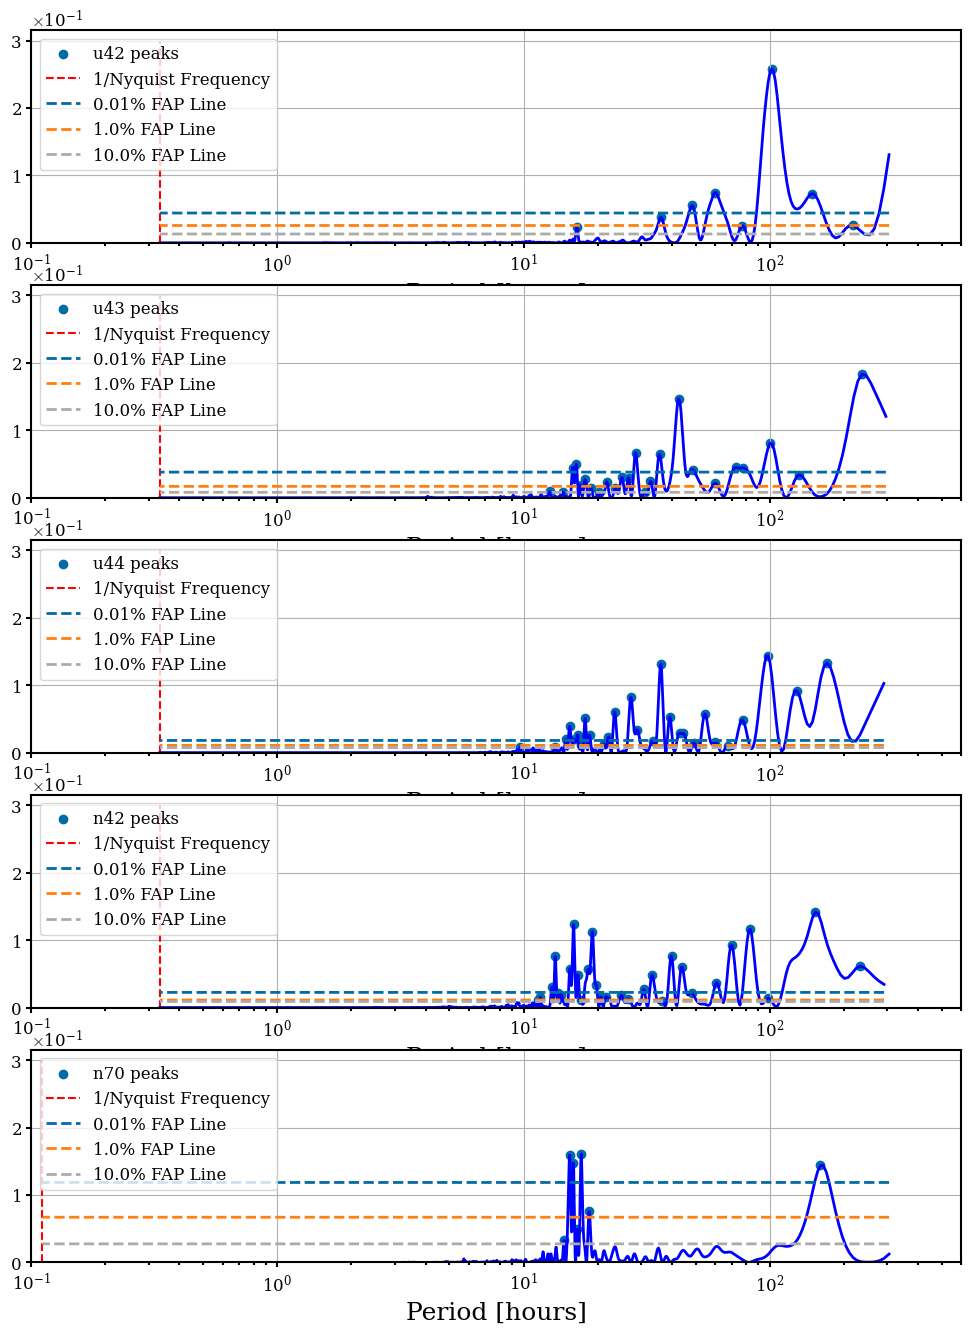

In [20]:
from figures import plot_periodogram
from fullsector import nyquist_from_cadence

max_freq_arr = nyquist_from_cadence(sample_cadences)

periodogram_list = []
for sector in planet_sectors:
    periodogram_list.append(np.load(root + "periodograms/" + f"{sector}_periodogram.npz"))

fig, axs = plt.subplots(5, figsize=(12, 16))

for i, pgram in enumerate(periodogram_list):
    # print(pgram.keys())
    frequency, power, fap_stack = pgram['frequency'], pgram['power'], pgram['false_alarm_levels']
    axs[i].scatter(24/pgram['peaks'], pgram['peak_pows'], label=f"{planet_sectors[i]} peaks")
    axs[i].vlines(1/max_freq_arr[i], 0, 0.3, color="red", linestyle="dashed", label="1/Nyquist Frequency")
    plot_periodogram(axs[i], frequency, power, fap_stack, color='blue', xlim=[1e-1, 600], legend_loc="upper left")
    axs[i].set_xscale("log")

    print(f"smallest peak: {np.min(24/pgram['peaks'])*60} minutes")
plt.show()


100%|██████████| 10000/10000 [19:03<00:00,  8.75it/s]
/home/ktp9/anaconda3/envs/TESSNeptune24/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


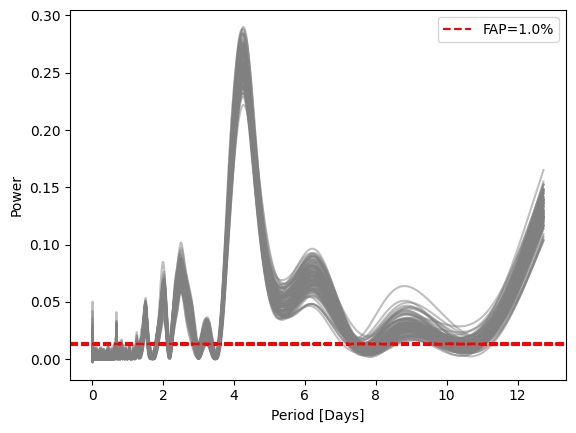

100%|██████████| 10000/10000 [19:16<00:00,  8.64it/s]


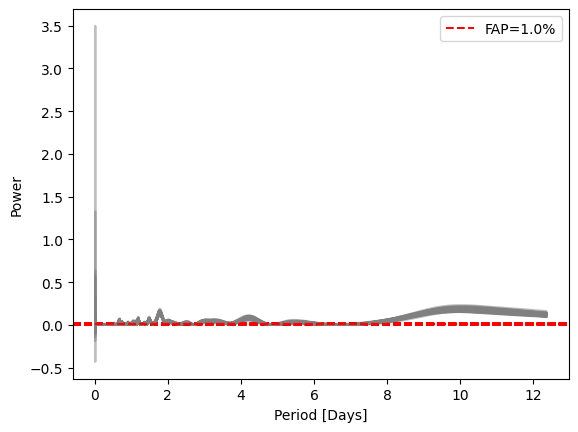

100%|██████████| 10000/10000 [19:09<00:00,  8.70it/s]


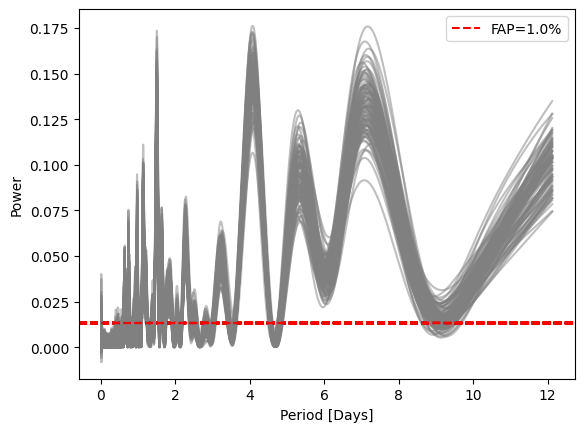

100%|██████████| 10000/10000 [19:10<00:00,  8.69it/s]


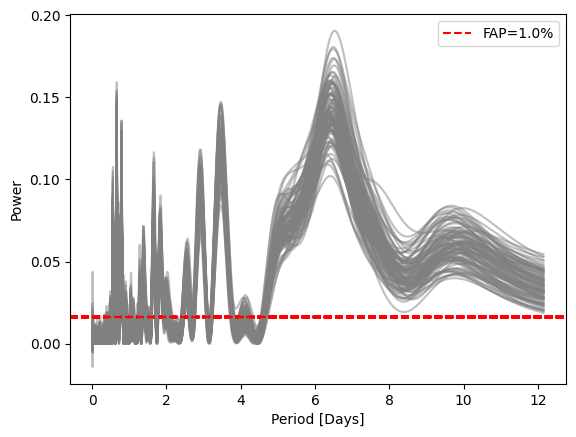

100%|██████████| 10000/10000 [19:56<00:00,  8.36it/s]


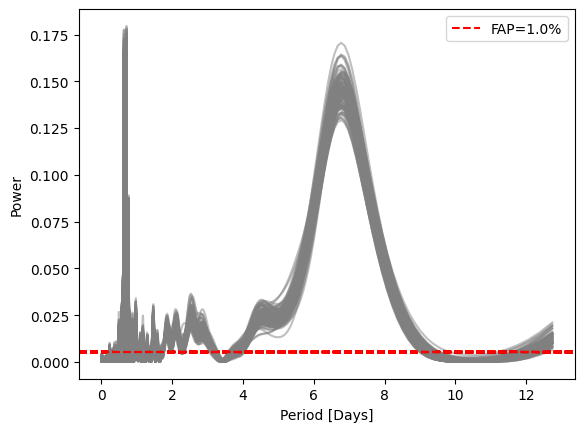

In [8]:
## now we bootstrap to get uncertainties on the peak frequencies (~100m)
from bootstrap import save_bootstrap
    
save_bootstrap(lc_list, 
               [f"{sector}" for sector in planet_sectors], 
               root + "bootstrap/", fap_level=0.01, 
               min_period_arr=1/max_freq_arr,
               max_period_arr=1/min_freq_arr)

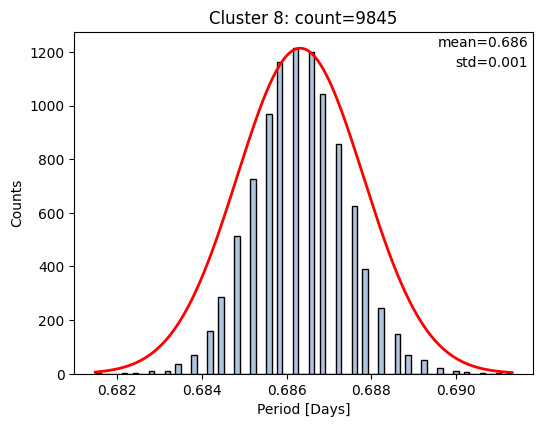

Sector: u42
0 out of 1 All means: [0.6863248363740984]
5 Peak periods from periodogram: [6.20988283 4.24341994 2.49612937 2.02067616 1.50653962]
matched means: []
matched stds: []



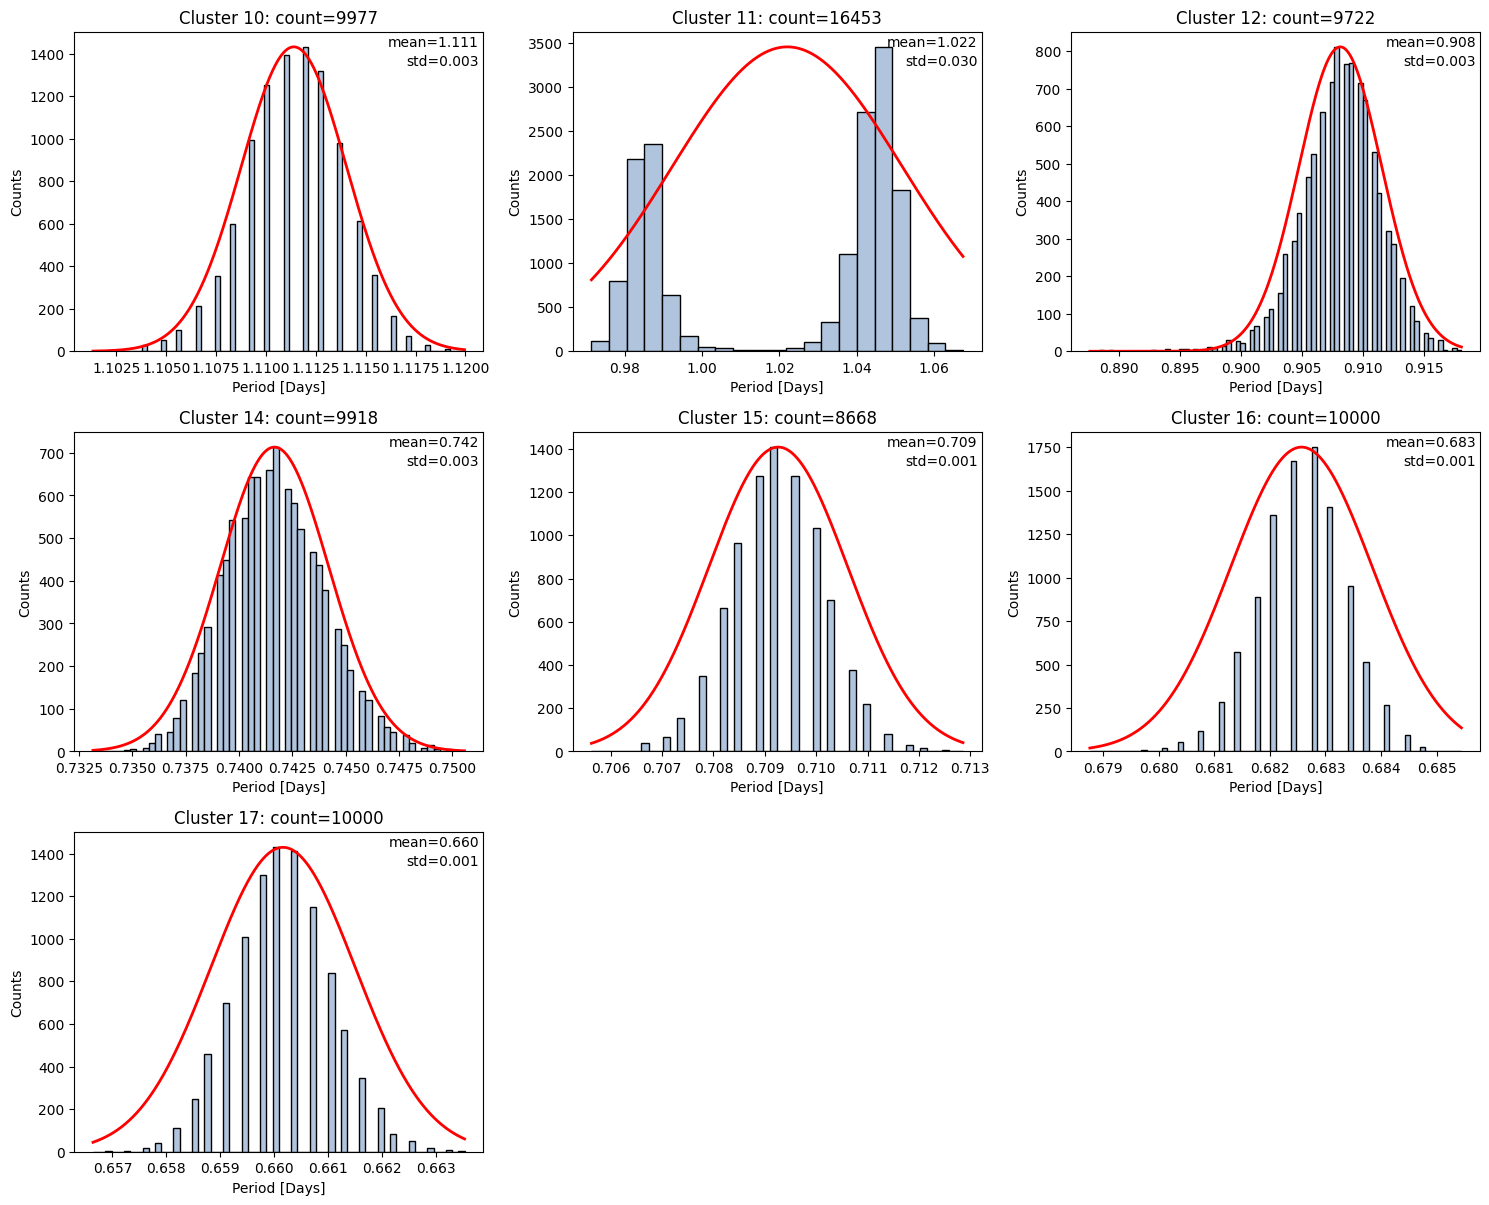

Sector: u43
6 out of 7 All means: [1.1113974557670436, 1.0220205559758202, 0.9081440281017011, 0.7416602548725383, 0.7092617859391475, 0.6825682107050739, 0.6601639836314583]
18 Peak periods from periodogram: [9.88672211 5.49262339 4.18928903 3.25221122 3.05145744 2.496647
 2.02596765 1.77818743 1.48896417 1.36556935 1.18830795 1.11336961
 1.04732226 0.90870608 0.7422464  0.71025303 0.68278468 0.66087715]
matched means: [1.11139746 0.90814403 0.74166025 0.70926179 0.68256821 0.66016398]
matched stds: [0.00263959 0.00340176 0.00254495 0.00135233 0.00127431 0.00133783]



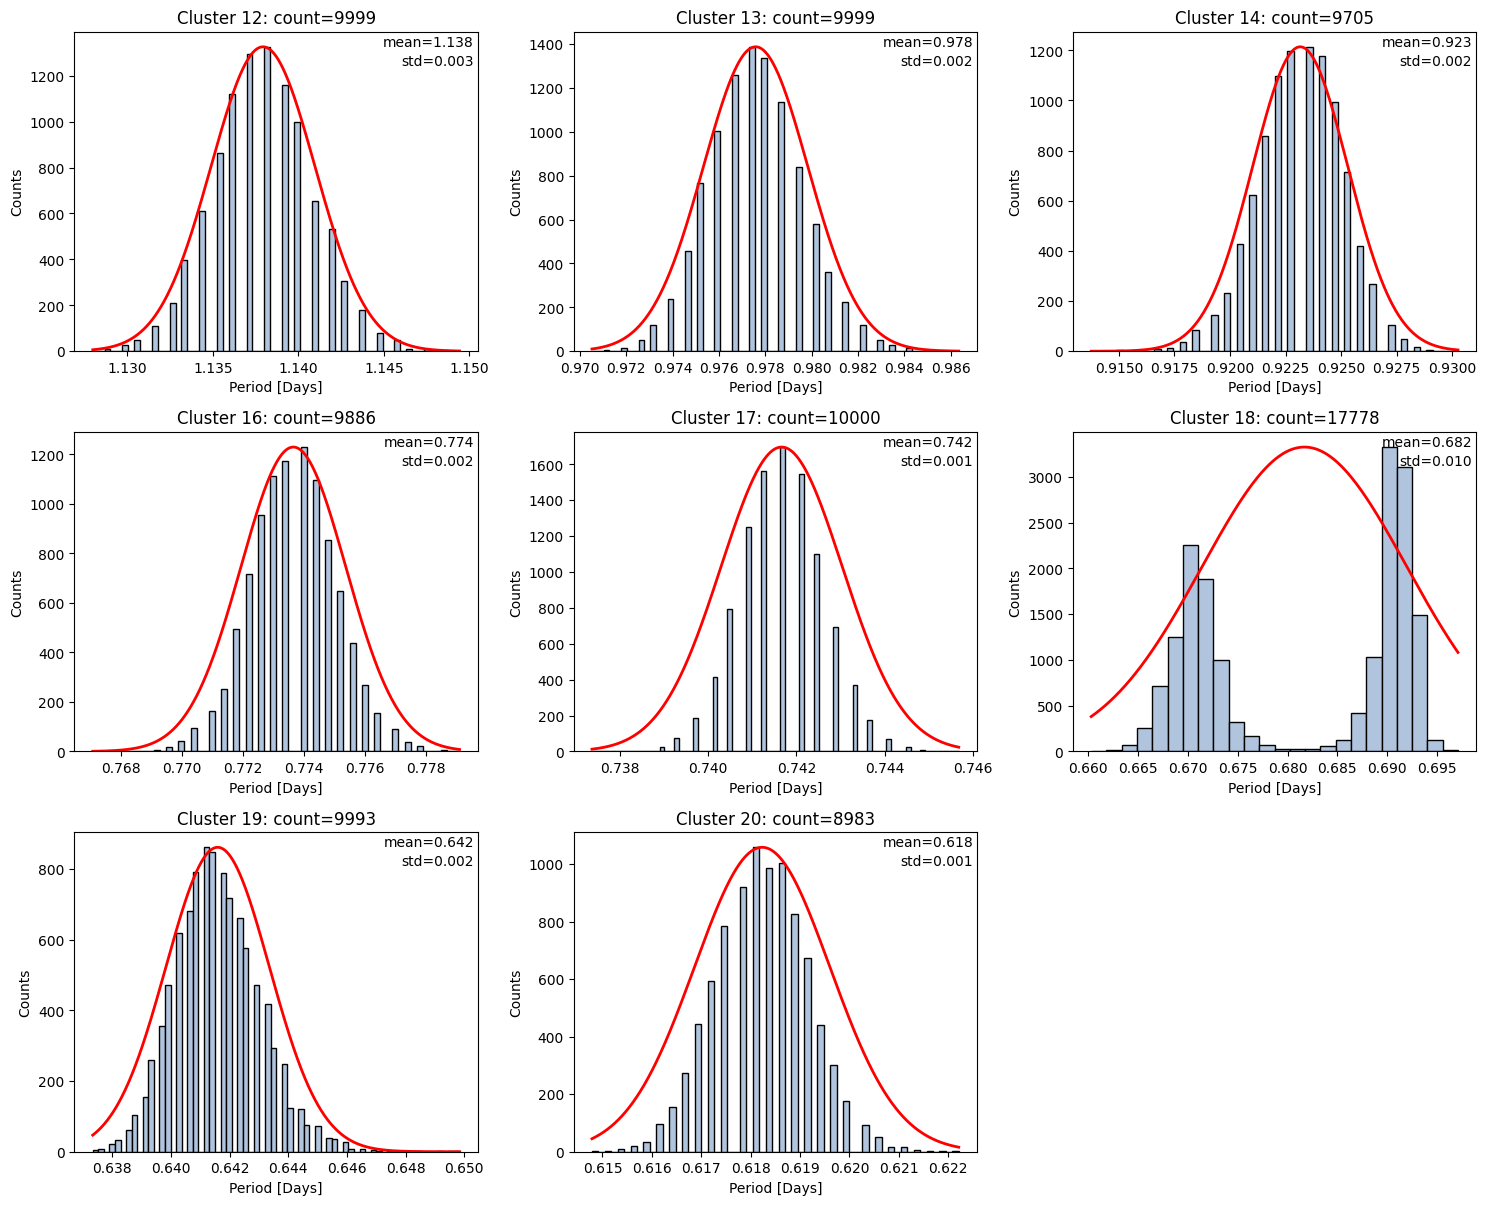

Sector: u44
7 out of 8 All means: [1.1379328818557415, 0.9775833461796047, 0.9231608789286038, 0.7736484881900255, 0.7416660758754864, 0.6816977620515233, 0.6415900721602495, 0.6182336101935837]
24 Peak periods from periodogram: [7.13049005 5.38748137 4.10909596 3.23248882 2.49934703 2.26576319
 2.05454798 1.85066154 1.79582712 1.63808555 1.50581777 1.39331415
 1.20615255 1.13820029 0.97756718 0.9218124  0.88480533 0.77455802
 0.74139652 0.713049   0.69070274 0.6715697  0.64136683 0.61846087]
matched means: [1.13793288 0.97758335 0.92316088 0.77364849 0.74166608 0.64159007
 0.61823361]
matched stds: [0.00304176 0.00225301 0.00214166 0.00172018 0.00137327 0.00176611
 0.001372  ]



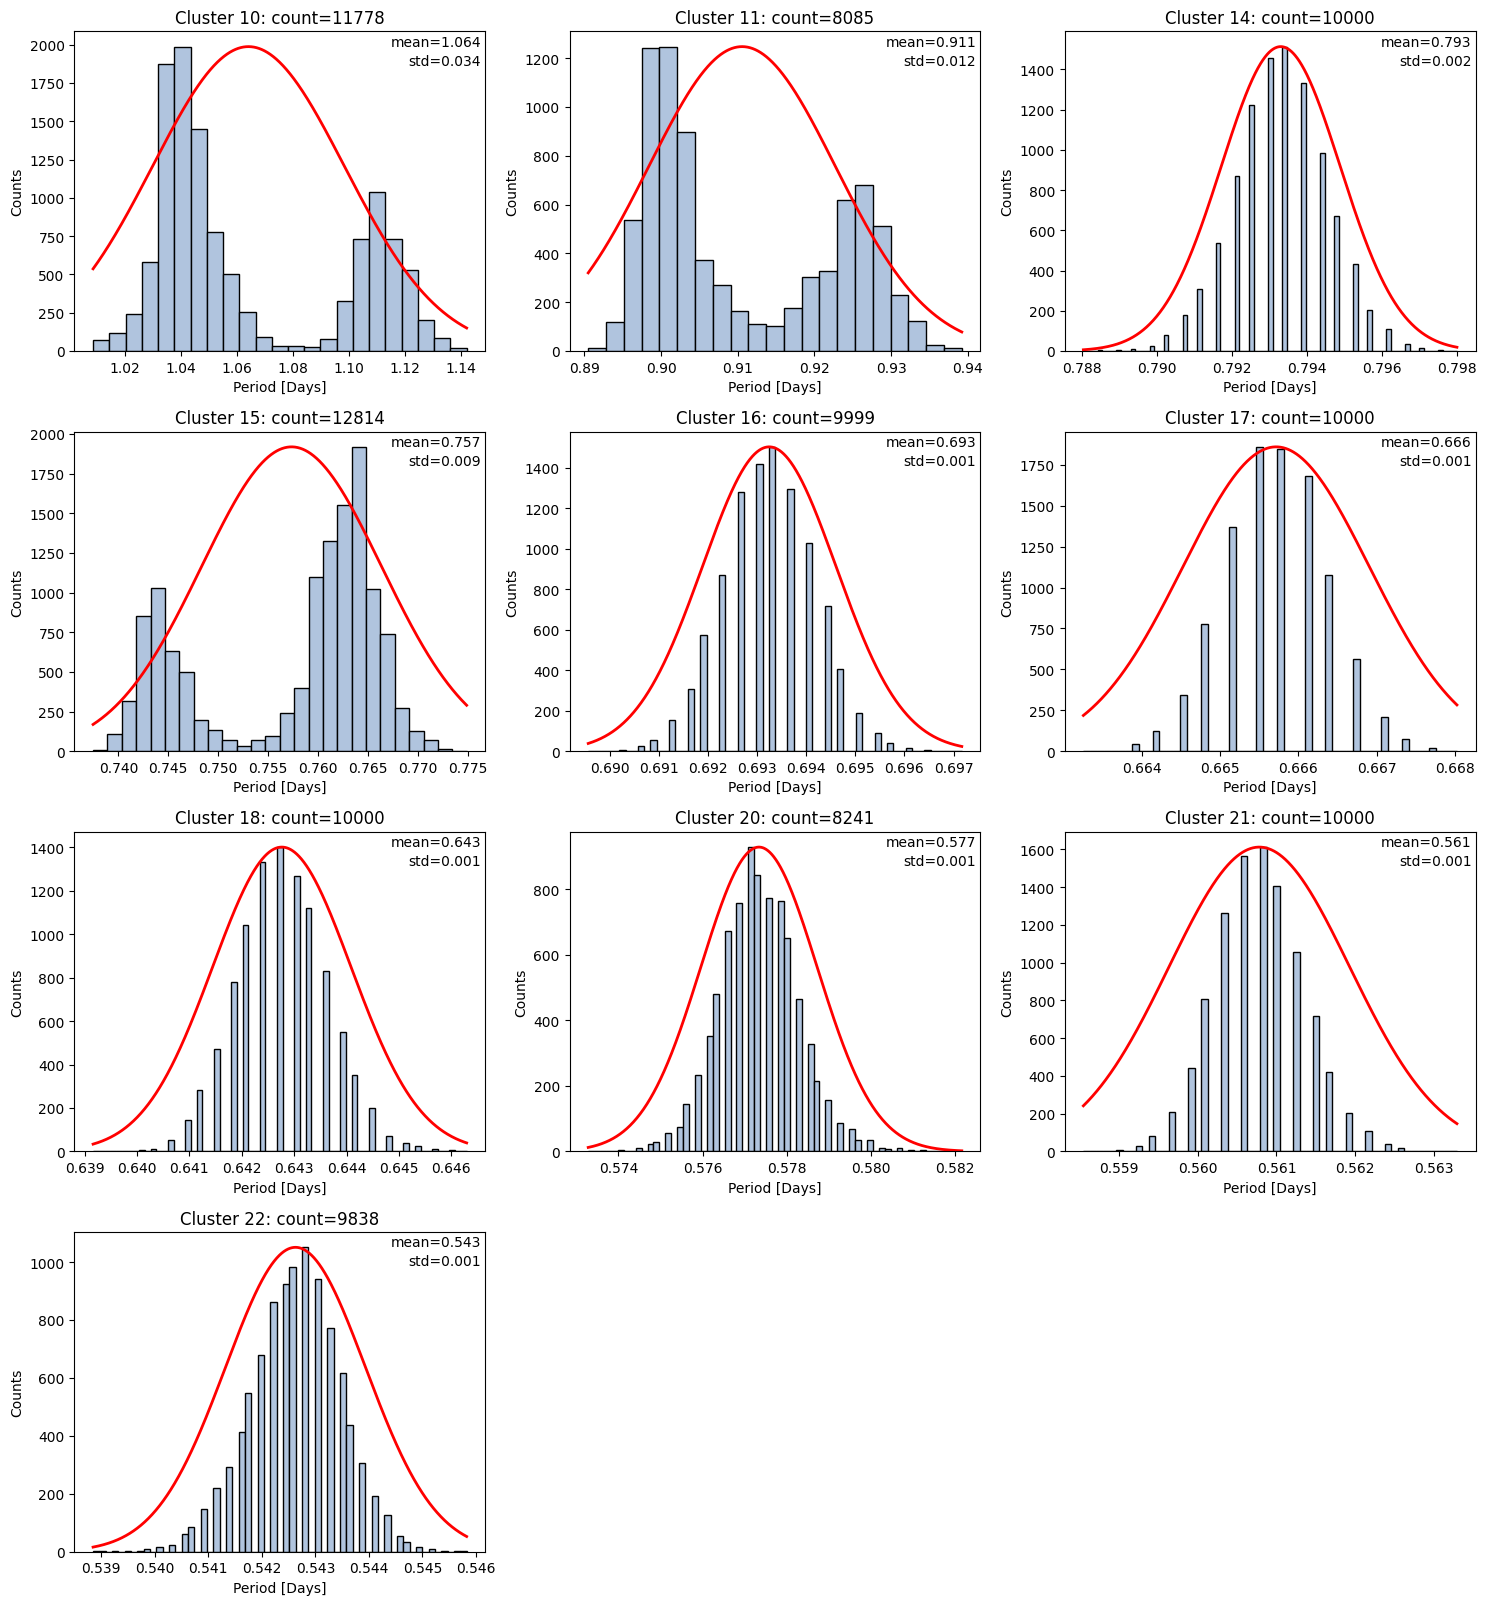

Sector: n42
7 out of 10 All means: [1.0642045890868337, 0.9105674590542395, 0.7933026338224389, 0.7573444630975841, 0.6932475354753675, 0.6657152064375054, 0.6427655233925099, 0.5773417838259713, 0.5607820718201699, 0.5426287732626389]
27 Peak periods from periodogram: [9.71968769 6.39453138 4.11851173 3.47131703 2.92761677 2.53116867
 2.00819994 1.82700896 1.66433008 1.38852681 1.28567297 1.10955339
 1.03842817 0.9033167  0.85862965 0.82091957 0.79409213 0.76412639
 0.71468292 0.69228545 0.66573203 0.64283649 0.59411294 0.5771786
 0.56118289 0.54239329 0.48793613]
matched means: [0.79330263 0.69324754 0.66571521 0.64276552 0.57734178 0.56078207
 0.54262877]
matched stds: [0.00158472 0.00136119 0.00119218 0.00132042 0.00138157 0.00114909
 0.00130669]



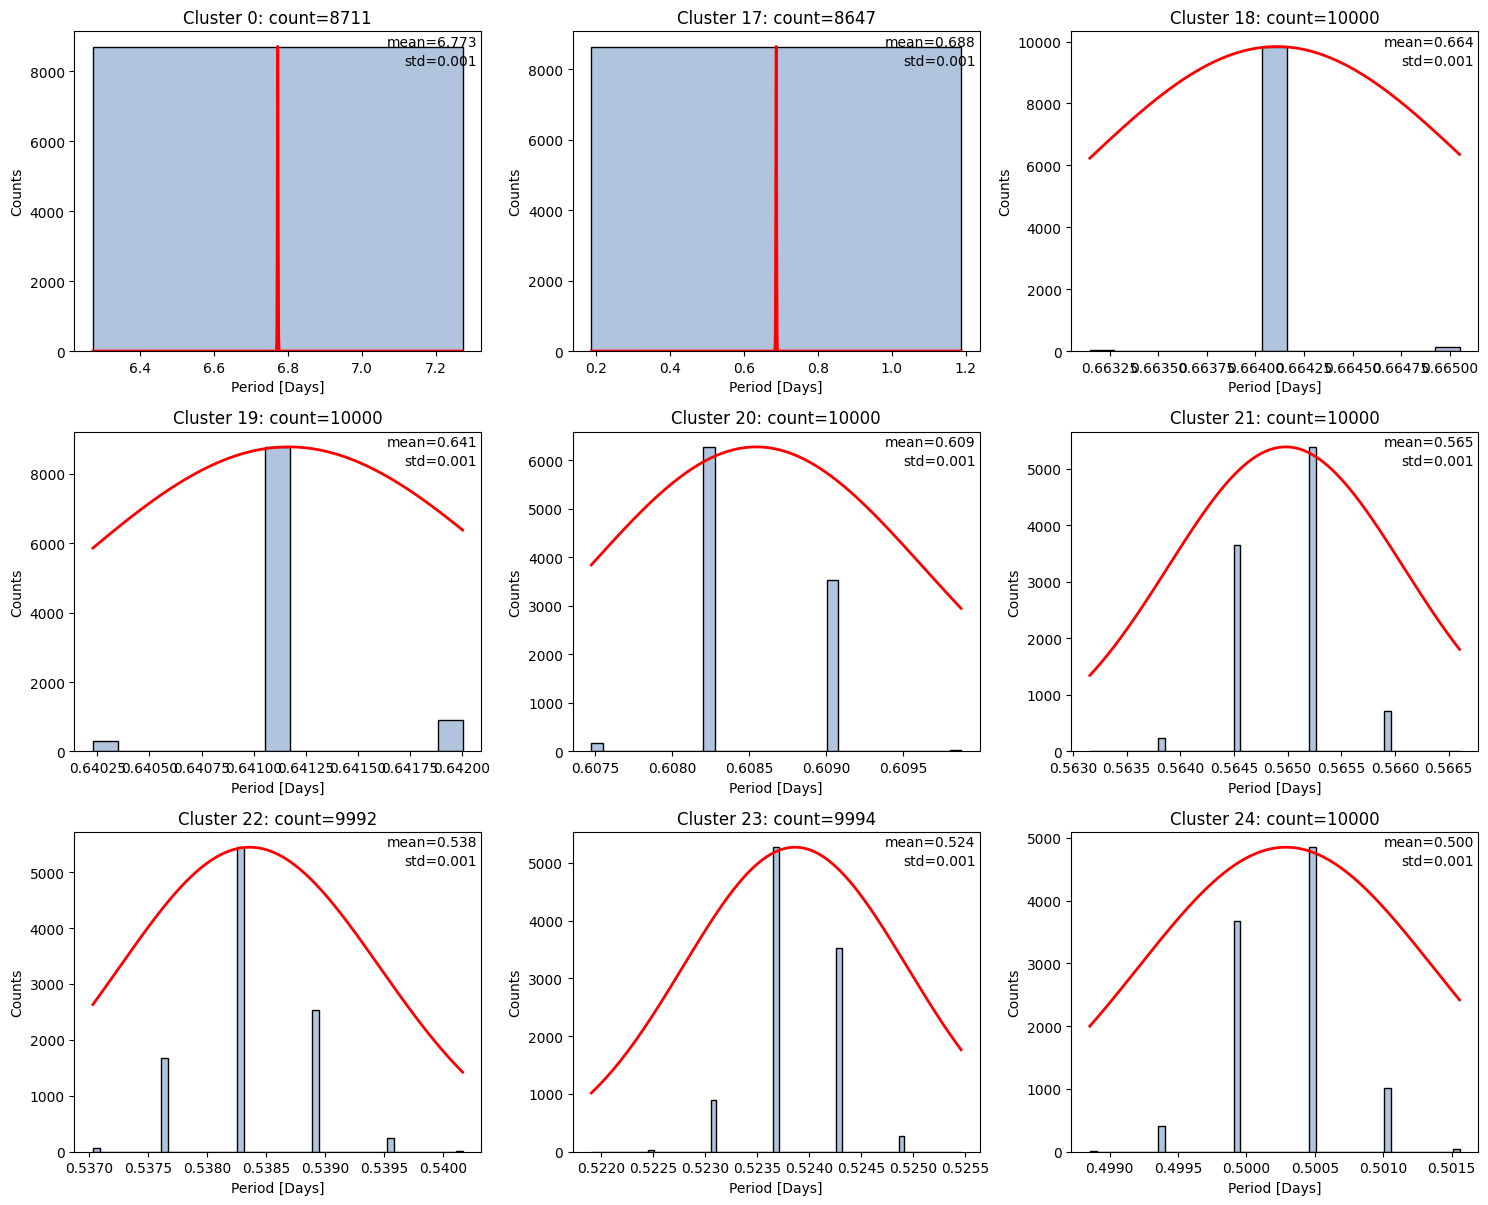

Sector: n70
2 out of 9 All means: [6.773093691523962, 0.6877669579681503, 0.6641094340725071, 0.64116813017848, 0.6085475253398993, 0.5649812101777377, 0.5383626610248154, 0.5238619302999304, 0.5002881246076226]
5 Peak periods from periodogram: [6.70060838 0.77158521 0.71523348 0.66481232 0.64136806]
matched means: [0.66410943 0.64116813]
matched stds: [0.00100722 0.00104568]



In [ ]:
# now, cluster the bootstrapped periodograms with dbscan (30s)
from bootstrap import save_cluster

periodogram_list = []
bootstrap_list = []
for sector in planet_sectors:
    periodogram_list.append(np.load(root + "periodograms/" + f"{sector}_periodogram.npz"))
    bootstrap_list.append(np.load(root + "bootstrap/" + f"{sector}_bootstrap.npz")["peak_periods"])

save_cluster(periodogram_list, 
             bootstrap_list, 
             [f"{sector}" for sector in planet_sectors], 
             root + "clusters/",
             eps_arr=[0.001, 0.001, 0.001, 0.001, 0.005], tolerance= 0.005,
             n_cols=3, min_prominence_arr=[0.5, 0.5, 0.5, 0.4, 5],
             plot=True)

In [14]:
# next lets import in some wind equations to interpret the frequencies we found
from wind_equations import *

ur_wind_eqns = [sromovsky2012_odd_N, sromovsky2012_odd_S, sromovsky2015_N, sromovsky2015_S]
# ur_wind_eqn_errs = [sigma_sromovsky2012_odd_N, sigma_sromovsky2012_odd_S, sigma_sromovsky2015_N, sigma_sromovsky2015_S]
ur_wind_eqn_errs = [sigma_uranus_model(wind_eqn) for wind_eqn in ur_wind_eqns]
ur_wind_eqn_strings = ["sromovsky2012_odd_N", "sromovsky2012_odd_S", "sromovsky2015_N", "sromovsky2015_S"]

nep_wind_eqns = [sromovsky1993_four, sromovsky1993_six, tollefson2013_kp, tollefson2014_kp]
nep_wind_eqn_errs = [sromovsky1993_four_err, sromovsky1993_six_err, tollefson2013_kp_err, tollefson2014_kp_err]
nep_wind_eqn_strings = ["sromovsky1993_four", "sromovsky1993_six", "tollefson2013_kp", "tollefson2014_kp"]

# planet data
uRe = 25559 * 1000
uRp = 24973 * 1000
uP = -17.247864
uRe_err = 4000
uRp_err = 20000
uP_err = 0.00001

nRe = 24764 * 1000
nRp = 24341 * 1000
nP = 15.9663
nRe_err = 15000
nRp_err = 30000
nP_err = 0.0002

reperr12 = 0.088 # degrees/h, pg. 11 of Sromovsky+ 2012c
reperr15 = 0.147 / 24 # 0.147 degrees/day, pg. 11 of Sromovsky+ 2015
reperrs = [reperr12, reperr12, reperr15, reperr15]


In [ ]:
from mcmc import run_mcmc

f_obs = 1.6
f_err = 0.1
model_eqn = nep_wind_eqns[0]  # choose a wind equation to test
sigma_eqn = sigma(nRe, nRp, nP, nRe_err, nRp_err, nP_err, nep_wind_eqn_errs[0])
freq_eqn = RHS(nRe, nRp, nP)  # string for plotting
sampler = run_mcmc(f_obs, f_err, model_eqn, sigma_eqn, freq_eqn, n_walkers=32, n_steps=5000)

samples = sampler.get_chain(discard=1000, flat=True)
phi_samples = samples[:, 0]

# Convert to degrees 
phi_deg = np.array(np.degrees(phi_samples))

100%|██████████| 5000/5000 [00:46<00:00, 107.68it/s]


(array([2.97895427e-04, 3.01031168e-04, 3.01031168e-04, 4.26460821e-04,
        4.48411011e-04, 4.17053597e-04, 5.92655112e-04, 7.52577920e-04,
        7.68256627e-04, 1.17276726e-03, 1.62744975e-03, 2.04763909e-03,
        2.88801777e-03, 3.68449607e-03, 5.59102680e-03, 8.13724876e-03,
        1.13827410e-02, 1.49700291e-02, 2.15582217e-02, 2.90651864e-02,
        3.78139047e-02, 4.76475896e-02, 5.37967783e-02, 5.49162380e-02,
        4.67978037e-02, 3.27684969e-02, 1.60205025e-02, 4.34613749e-03,
        8.15292747e-04, 2.19501893e-05]),
 array([4.73098992e-02, 2.53874627e+00, 5.03018264e+00, 7.52161900e+00,
        1.00130554e+01, 1.25044917e+01, 1.49959281e+01, 1.74873645e+01,
        1.99788008e+01, 2.24702372e+01, 2.49616736e+01, 2.74531099e+01,
        2.99445463e+01, 3.24359827e+01, 3.49274191e+01, 3.74188554e+01,
        3.99102918e+01, 4.24017282e+01, 4.48931645e+01, 4.73846009e+01,
        4.98760373e+01, 5.23674736e+01, 5.48589100e+01, 5.73503464e+01,
        5.98417827e+01

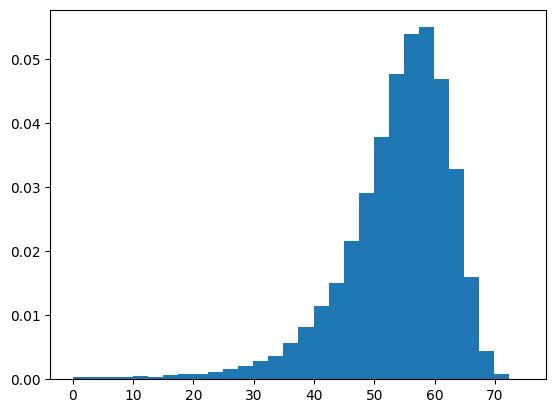

In [ ]:
import matplotlib.pyplot as plt

plt.hist(phi_deg, bins=30, density=True)

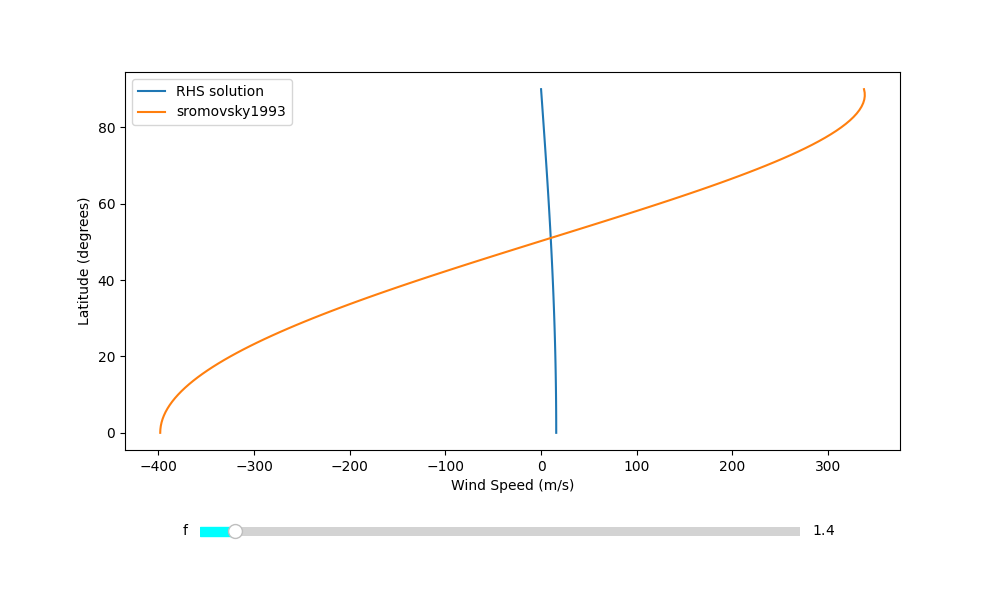

In [6]:
%matplotlib ipympl
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
import numpy as np

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 6))
plt.subplots_adjust(bottom=0.25)  # Make room for slider

phi = np.linspace(0, np.pi/2, 100)
solution = RHS(uRe, uRp, uP)

# Initial plot
line1, = ax.plot(solution(phi, 1.4), phi*180/np.pi, label="RHS solution")
line2, = ax.plot(sromovsky1993_four(phi), phi*180/np.pi, label="sromovsky1993")
ax.set_xlabel("Wind Speed (m/s)")
ax.set_ylabel("Latitude (degrees)")
ax.legend()

# Create slider axis
ax_slider = plt.axes([0.2, 0.1, 0.6, 0.03])
slider = Slider(ax_slider, 'f', 1.3, 3, valinit=1.4, color='cyan')

# Update function
def update(val):
    f_val = slider.val
    line1.set_xdata(solution(phi, f_val))
    fig.canvas.draw_idle()

slider.on_changed(update)

plt.show()


In [ ]:
# run mcmc fits for each cluster and save the results (~115m)
from mcmc import save_mcmc 
# planet_sectors = ["u43"]
# load in the clusters

cluster_list = []
for sector in planet_sectors:
    cluster_list.append(np.load(root + "clusters/" + f"{sector}_clustered_peaks.npz", allow_pickle=True))

for i, cluster in enumerate(cluster_list):
    # frequencies = periodogram['peaks']
    # frequency_errs = periodogram['peak_std']

    if planet_sectors[i][0] == "u":
        save_mcmc(ur_wind_eqns, ur_wind_eqn_errs, cluster,
                  uRe, uRp, uP, uRe_err, uRp_err, uP_err, 
                  ur_wind_eqn_strings, f"{planet_sectors[i]}", root + "mcmc/", reperrs=reperrs)
    elif planet_sectors[i][0] == "n":
        print('skipping neptune')
        # save_mcmc(nep_wind_eqns, nep_wind_eqn_errs, cluster, 
        #           nRe, nRp, nP, nRe_err, nRp_err, nP_err, 
        #           nep_wind_eqn_strings, f"{planet_sectors[i]}", root + "mcmc/")

/home/ktp9/anaconda3/envs/TESSNeptune24/lib/python3.11/site-packages/scipy/optimize/_optimize.py:2291: RuntimeWarning: invalid value encountered in scalar subtract
  p = (xf - fulc) * q - (xf - nfc) * r
/home/ktp9/anaconda3/envs/TESSNeptune24/lib/python3.11/site-packages/scipy/optimize/_optimize.py:2292: RuntimeWarning: invalid value encountered in scalar subtract
  q = 2.0 * (q - r)


Minimum f with at least one intersection: 1.360531
Minimum f with at least one intersection: 1.360531
Minimum f with at least one intersection: 1.369822
Minimum f with at least one intersection: 1.369822
Using minimum frequency of 1.3605305096908973 for wind equation sromovsky2012_odd_N
Processing wind equation: sromovsky2012_odd_N
Frequency, error: 1.4570261762165395 0.0031203899696476667


 22%|██▏       | 1098/5000 [00:20<01:13, 53.33it/s]

100%|██████████| 5000/5000 [01:48<00:00, 46.03it/s]


Median latitude (deg): 36.42545464339558
Using minimum frequency of 1.3605305096908973 for wind equation sromovsky2012_odd_S
Processing wind equation: sromovsky2012_odd_S
Frequency, error: 1.4570261762165395 0.0031203899696476667


...

Median latitude (deg): 58.51892794503057
Frequency, error: 1.5595922449434225 0.002522663100446458


100%|██████████| 5000/5000 [00:55<00:00, 90.42it/s] 


Median latitude (deg): 64.86839144112227
Frequency, error: 1.6432350953909973 0.0028341011089497176


100%|██████████| 5000/5000 [01:13<00:00, 68.16it/s] 


Median latitude (deg): 69.18277841046117


In [13]:
from mcmc import save_mcmc 

periodogram_list = []
for sector in planet_sectors:
    periodogram_list.append(np.load(root + "periodograms/" + f"{sector}_periodogram.npz", allow_pickle=True))

for i, periodogram in enumerate(periodogram_list[0:1]):
    frequencies = periodogram['peaks']
    frequency_errs = periodogram['peak_std']

    if planet_sectors[i][0] == "u":
        save_mcmc(ur_wind_eqns, ur_wind_eqn_errs, frequencies, frequency_errs,
                  uRe, uRp, uP, uRe_err, uRp_err, uP_err, 
                  ur_wind_eqn_strings, f"{planet_sectors[i]}", root + "mcmc/", reperrs=reperrs, n_steps=10000)

/home/ktp9/anaconda3/envs/TESSNeptune24/lib/python3.11/site-packages/scipy/optimize/_optimize.py:2291: RuntimeWarning: invalid value encountered in scalar subtract
  p = (xf - fulc) * q - (xf - nfc) * r
/home/ktp9/anaconda3/envs/TESSNeptune24/lib/python3.11/site-packages/scipy/optimize/_optimize.py:2292: RuntimeWarning: invalid value encountered in scalar subtract
  q = 2.0 * (q - r)


Minimum f with at least one intersection: 1.360531
Minimum f with at least one intersection: 1.360531
Minimum f with at least one intersection: 1.369822
Minimum f with at least one intersection: 1.369822
Using minimum frequency of 1.3605305096908973 for wind equation sromovsky2012_odd_N
Processing wind equation: sromovsky2012_odd_N
Frequency, error: 1.4556073550737367 0.16427334565428944


100%|██████████| 10000/10000 [02:28<00:00, 67.40it/s]


Median latitude (deg): 34.5347228657685
Using minimum frequency of 1.3605305096908973 for wind equation sromovsky2012_odd_S
Processing wind equation: sromovsky2012_odd_S
Frequency, error: 1.4556073550737367 0.16427334565428944


100%|██████████| 10000/10000 [02:30<00:00, 66.53it/s]


Median latitude (deg): 34.917137700704075
Using minimum frequency of 1.369822244200759 for wind equation sromovsky2015_N
Processing wind equation: sromovsky2015_N
Frequency, error: 1.4556073550737367 0.16427334565428944


100%|██████████| 10000/10000 [02:16<00:00, 73.04it/s]


Median latitude (deg): 35.327381370938475
Using minimum frequency of 1.369822244200759 for wind equation sromovsky2015_S
Processing wind equation: sromovsky2015_S
Frequency, error: 1.4556073550737367 0.16427334565428944


100%|██████████| 10000/10000 [02:23<00:00, 69.88it/s]


Median latitude (deg): 33.45437945786669


In [10]:
# load the mcmc posteriors back in
mcmc_dir = root + "mcmc/"

mcmc_list = []
for sector in planet_sectors:
    mcmc_list.append(np.load(mcmc_dir + f"{sector}_phi_distributions.npz", allow_pickle=True))

In [ ]:
# we now have posterior distributions for each solution, lets get one sigma interval ~10m
from mcmc import fit_all_distributions

for i, phi_dist in enumerate(mcmc_list):
    print(len(phi_dist["phi_distributions"][0]))
# phi_dist = mcmc_list[1]
    print(f"Planet sector: {planet_sectors[i]}")

    all_latitudes, all_standard_devs = fit_all_distributions(phi_dist["phi_distributions"], phi_dist["wind_eqn_strings"], plot=False)

    np.savez(root + "latitudes/" + f"{planet_sectors[i]}_latitude_solutions.npz", 
                lat=np.array(all_latitudes, dtype=object), std=np.array(all_standard_devs, dtype=object), allow_pickle=True)

1
Planet sector: u42
Processing Wind Equation: sromovsky2012_odd_N
Skewness: -0.085, Mean: 36.417, Std: 0.430, Mu0: 36.417, Sigma0: 0.430, Mu1: 36.417, Sigma1: 0.430
Processing Wind Equation: sromovsky2012_odd_S
Skewness: -0.083, Mean: 34.654, Std: 0.547, Mu0: 34.654, Sigma0: 0.547, Mu1: 34.654, Sigma1: 0.547
Processing Wind Equation: sromovsky2015_N
Skewness: -0.099, Mean: 36.369, Std: 0.470, Mu0: 36.369, Sigma0: 0.470, Mu1: 36.369, Sigma1: 0.470
Processing Wind Equation: sromovsky2015_S
Skewness: -0.076, Mean: 34.735, Std: 0.609, Mu0: 34.735, Sigma0: 0.609, Mu1: 34.735, Sigma1: 0.609
& Eqn 1 & Eqn 2 & Eqn 3 & Eqn 4
& 36.42 ± 0.43 & 34.65 ± 0.55 & 36.37 ± 0.47 & 34.74 ± 0.61 \\
3
Planet sector: u43
Processing Wind Equation: sromovsky2012_odd_N
Skewness: -0.203, Mean: 27.545, Std: 0.758, Mu0: 27.545, Sigma0: 0.758, Mu1: 27.545, Sigma1: 0.758
Skewness: -0.082, Mean: 37.473, Std: 0.352, Mu0: 37.473, Sigma0: 0.352, Mu1: 37.473, Sigma1: 0.352
Skewness: -0.019, Mean: 43.057, Std: 0.315, Mu0

In [61]:
## a simple program to filter to a specific fap value

#pull necessary data
periodogram_list, cluster_list, latsol_list = [], [], []
for sector in planet_sectors:
    periodogram_list.append(np.load(root + "periodograms/" + f"{sector}_periodogram.npz", allow_pickle=True))
    cluster_list.append(np.load(root + "clusters/" + f"{sector}_clustered_peaks.npz", allow_pickle=True))
    latsol_list.append(np.load(root + "latitudes/" + f"{planet_sectors[i]}_latitude_solutions.npz", allow_pickle=True))

print(periodogram_list[0].keys)
for i, periodogram in enumerate(periodogram_list):
    if i <= 2:
        min_freq_arr = get_minimum_frequency_arr(ur_wind_eqns, uRe, uRp, uP)
    elif i > 2:
        min_freq_arr = get_minimum_frequency_arr(nep_wind_eqns, nRe, nRp, nP)

    peak_lat_idxs = periodogram['peaks'] > min_freq_arr[0]
    one_p = periodogram['false_alarm_levels'][2]

    mm = cluster_list[i]['matched_means']
    std = cluster_list[i]['matched_stds']

    arr1 = 24/periodogram['peaks']
    # print((periodogram['peaks'] > min_freq_arr[0]))
    arr2 = 24*mm[1/mm > min_freq_arr[0]]
    arr3 = 24*std[1/mm > min_freq_arr[0]]
#    print(one_p[0])
    indices = np.argmin(np.abs(arr1[:, np.newaxis] - arr2), axis=0)
    print(arr1[indices])  # Output: [19 20 21]
    print(arr2, "\n", arr3)

    peak_pows = periodogram['peak_pows'][indices]

    print(peak_pows > one_p[0])

    # print(len(latsol_list[i]['lat'][0]))
    # print(len(peak_pows[peak_pows > one_p[0]]))

    # print(mm[1/mm > min_freq_arr[0]], "days")

<bound method Mapping.keys of NpzFile '/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/periodograms/u42_periodogram.npz' with keys: frequency, power, false_alarm_levels, peaks, peak_pows>
Minimum f with at least one intersection: 1.360531
Minimum f with at least one intersection: 1.360531
Minimum f with at least one intersection: 1.369822
Minimum f with at least one intersection: 1.369822
[16.470417]
[16.47190723] 
 [0.03527649]
[False]
Minimum f with at least one intersection: 1.360531
Minimum f with at least one intersection: 1.360531
Minimum f with at least one intersection: 1.369822
Minimum f with at least one intersection: 1.369822
[17.0460726  16.38683222 15.86105151]
[17.02237015 16.38164634 15.84382844] 
 [0.03236682 0.03040346 0.03190722]
[False  True  True]
Minimum f with at least one intersection: 1.360531
Minimum f with at least one intersection: 1.360531
Minimum f with at least one intersection: 1.369822
Minimum f with at least one intersection: 1.369822
[16.57686576 1